# Face Alignment

## Архитектура Stacked Hourglass Network

В разных вариантах пайплайна для распознавания лиц ключевые точки лица могут предсказываться сразу детектором (MTCNN, RetinaFace и прочие), а могут и отдельной моделью. В этом проекте рассматривается второй вариант. То есть, за детекцию ключевых точек будет отвечать отдельная модель.

**Hourglass** — это U-Net-подобная структура, которая сначала уменьшает разрешение изображения, затем восстанавливает его обратно. Такая структура напоминает по форме песочные часы (hourglass).

**Stacked Hourglass Network** состоит Hourglass-блоков, каждый из которых старается уточнять результат предыдущего. Несмотря на то, что она придумана в 2016 году, до сих пор используется во многих исследовательских проектах для задачи обнаружения ключевых точек.

![image](https://img2018.cnblogs.com/blog/900393/201907/900393-20190722093153502-1808128161.png)

### Hourglass module

Посмотрим подробнее на структуру **отдельного Hourglass-блока**

![retrt](https://curt-park.github.io/images/stacked_hourglass_networks/fig3.png)

Каждый бокс в этой схеме - это Residual block, который отвечает за извлечение признаков на разных уровнях детализации (вспоминаем про ResNet). Причем, каждый такой блок имеет одинаковую размерность на входе и на выходе.

Downsampling и upsampling можно делать разными способами.

*   Для Downsampling: nn.MaxPool2d или nn.Conv2d
*   Для Upsampling: nn.Upsample или nn.ConvTranspose2d

Основная разница: maxpool и upsample - необучаемые слои в отличие от сверток. Это может как быть как минусом, так и плюсом: чем больше параметров - тем медленее идет процесс обучения (при этом не факт, что результаты будут лучше).

То есть, идейно все практически также как было в U-net: полностью симметричная архитектура, сначала идет преобразование в более низкоразмерное пространство, а потом декодирование обратно с пробросами результатов из соотвествующих слоев энкодера. Разница лишь в том, что теперь каждый кирпичик - это Residual block.

А вот реализация ResidualBlock вам в помощь!

Но можете ее править под себя, если очень хочется.

In [ ]:
'''
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.skip = nn.Identity() if in_channels == out_channels else nn.Conv2d(in_channels, out_channels, 1)

        self.conv1 = nn.Conv2d(in_channels, out_channels // 2, 1)
        self.bn1 = nn.BatchNorm2d(out_channels // 2)
        self.conv2 = nn.Conv2d(out_channels // 2, out_channels // 2, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels // 2)
        self.conv3 = nn.Conv2d(out_channels // 2, out_channels, 1)
        self.bn3 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        residual = self.skip(x)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.bn3(self.conv3(x))
        return self.relu(x + residual)
'''

'\nclass ResidualBlock(nn.Module):\n    def __init__(self, in_channels, out_channels):\n        super().__init__()\n        self.skip = nn.Identity() if in_channels == out_channels else nn.Conv2d(in_channels, out_channels, 1)\n\n        self.conv1 = nn.Conv2d(in_channels, out_channels // 2, 1)\n        self.bn1 = nn.BatchNorm2d(out_channels // 2)\n        self.conv2 = nn.Conv2d(out_channels // 2, out_channels // 2, 3, padding=1)\n        self.bn2 = nn.BatchNorm2d(out_channels // 2)\n        self.conv3 = nn.Conv2d(out_channels // 2, out_channels, 1)\n        self.bn3 = nn.BatchNorm2d(out_channels)\n\n        self.relu = nn.ReLU(inplace=True)\n\n    def forward(self, x):\n        residual = self.skip(x)\n        x = self.relu(self.bn1(self.conv1(x)))\n        x = self.relu(self.bn2(self.conv2(x)))\n        x = self.bn3(self.conv3(x))\n        return self.relu(x + residual)\n'

При построении архитектуры Hourglass-блоков **не обязательно полностью повторять архитектуру**, которая представлена на картинке из статьи. Вы можете добавлять больше или меньше модулей, некоторые блоки вообще можно не использовать. В целом, это творческая задача и вы вольны делать так, как вам самим хочется. **Главное - чтобы ваша реализация соотвествовала изначальной идее Hourglass, и итоговые результаты были достаточно хорошими.**

### Stacked Hourglass Network

Как и было сказано ранее, Stacked Hourglass - это набор одинаковых Hourglass блоков (см. схематический рисунок в начале ноутбука). Но что это за блок между каждыми двумя Hourglass? Чтобы ответить на этот вопрос, нужно сначала разобраться с тем, что мы будем получать на выходе такой нейронной сети.

Предсказывать ключевые точки лица можно поразному. Есть два основных подхода:

1.   Регрессия - предсказывает координаты точек лица напрямую -> $(N, x, y)$.
2.   Heatmap - предсказывает карту вероятностей на выходе, а наиболее подходящие точки находятся через argmax

Не вдваясь в подробности, можно просто сказать, что Heatmap-подход показал себя лучше из-за своей устойчивости к шумам и начальным условиям. В качестве функции потерь в таком случае используют обычный **MSE loss**.

В Stacked Hourglass **используется именно heatmap-подход**. И на выходе каждого Hourglass-блока находится слой (голова), который создает heatmap нужного размера. Обычно это какие-то стандартные варианты по типу *Conv -> BatchNorm -> Relu -> Conv* или просто *Conv*. Каждая heatmap'a прокидывается на следующую голову, и они суммируются, и так, пока слои не закончатся.

Такой подход нужен для реализации **Intermediate Supervision**. Если говорить простыми словами, то это такой вариант обучения нейронной сети, когда мы подсчитываем лосс не только по финальному выходу сети, а также на некоторых промежуточных слоях (головах). Градиенты в этом случае тоже распространяются не только через последний выход, но и через промежуточные уровни. Эти головы не влияют на финальное предсказание напрямую, но помогают модели быстрее и лучше учиться. На практике это означет следующее:

Нужно посчитать лосс (таргет для всех одинаковый) для каждой головы отдельно, а потом просуммировать. Далее Pytorch сам построит за вас весь граф вычислений и правильно запустит везде градиенты. В коде это выглядит так:

```
outputs = model(image)  # outputs — список из N heatmaps от разных голов
losses = [loss_function(output, target) for output in outputs]
total_loss = sum(losses)
total_loss.backward()
optimizer.step()
```

Подведем **итоги по архитектуре**.

Stacked Hourglass состоит из Hourglass-блоков, после каждого такого блока идет голова, которая предсказывает heatmap'у. Каждая heatmap'а суммируется с предыдущей. Градиенты при обучении текут с каждой головы, а не только через последний выход сети.

Подробно про Stacked Hourglass Network можно прочитать в [оригинальной статье](https://arxiv.org/pdf/1603.06937).

## Скачиваем датасет

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls "/content/drive/MyDrive/DLS1/"

aligned_images	celeba_cropped.zip     person_id.csv
attrs.csv	landmarks_cropped.csv


In [ ]:
!cp "/content/drive/MyDrive/DLS1/attrs.csv" /content/
!cp "/content/drive/MyDrive/DLS1/person_id.csv" /content/
!cp "/content/drive/MyDrive/DLS1/landmarks_cropped.csv" /content/

In [ ]:
zip_path = "/content/drive/MyDrive/DLS1/celeba_cropped.zip"


# Распаковать в /content/celeba_cropped/
!unzip "$zip_path" -d /content/celeba_cropped/


Выходные данные были обрезаны до нескольких последних строк (5000).
  inflating: /content/celeba_cropped/content/celeba_cropped/142880.jpg  
  inflating: /content/celeba_cropped/content/celeba_cropped/074429.jpg  
  inflating: /content/celeba_cropped/content/celeba_cropped/036106.jpg  
  inflating: /content/celeba_cropped/content/celeba_cropped/139058.jpg  
  inflating: /content/celeba_cropped/content/celeba_cropped/132316.jpg  
  inflating: /content/celeba_cropped/content/celeba_cropped/179297.jpg  
  inflating: /content/celeba_cropped/content/celeba_cropped/023406.jpg  
  inflating: /content/celeba_cropped/content/celeba_cropped/056620.jpg  
  inflating: /content/celeba_cropped/content/celeba_cropped/010168.jpg  
  inflating: /content/celeba_cropped/content/celeba_cropped/101163.jpg  
  inflating: /content/celeba_cropped/content/celeba_cropped/083205.jpg  
  inflating: /content/celeba_cropped/content/celeba_cropped/177697.jpg  
  inflating: /content/celeba_cropped/content/celeba_crop

In [ ]:
import os

folder_path = '/content/celeba_cropped/content/celeba_cropped'
# Расширения изображений, которые учитываем
image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp'}

# Считаем файлы с указанными расширениями
count = 0
for filename in os.listdir(folder_path):
    if os.path.isfile(os.path.join(folder_path, filename)):
        if os.path.splitext(filename)[1].lower() in image_extensions:
            count += 1

print(count)

16686


In [ ]:
SOURCE_PATH="/content/celeba_cropped/content/celeba_cropped"
DEST_PATH="/content/celeba_cropped"
!mv "$SOURCE_PATH"/* "$DEST_PATH"

In [ ]:
# Выводим, сколько файлов распаковалось
!ls -1 /content/celeba_cropped/ | wc -l


# Выводим первые 10 файлов
!ls -l /content/celeba_cropped/ | head -10

16687
total 189860
-rw-r--r-- 1 root root 13810 Feb  3 12:47 000001.jpg
-rw-r--r-- 1 root root  7864 Feb  3 12:47 000015.jpg
-rw-r--r-- 1 root root  9255 Feb  3 12:47 000016.jpg
-rw-r--r-- 1 root root  9837 Feb  3 12:47 000018.jpg
-rw-r--r-- 1 root root  8035 Feb  3 12:47 000034.jpg
-rw-r--r-- 1 root root 11133 Feb  3 12:47 000052.jpg
-rw-r--r-- 1 root root 14002 Feb  3 12:47 000088.jpg
-rw-r--r-- 1 root root  5984 Feb  3 12:47 000100.jpg
-rw-r--r-- 1 root root  7273 Feb  3 12:47 000103.jpg


In [ ]:
import pandas as pd

landmarks_cropped = pd.read_csv("/content/landmarks_cropped.csv")
attrs = pd.read_csv("/content/attrs.csv")
person_id = pd.read_csv("/content/person_id.csv")

print(len(landmarks_cropped)) # длин адатасета с ландмарками
print(len(attrs)) # длина датасета с атрибутами (на всякйи случай)
print(len(person_id)) # длина датасета в айди персон (все три должны совпадать)

16686
16686
16686


Посмотрим на датасет с ключевыми точками лица:

In [ ]:
landmarks_cropped = landmarks_cropped.drop('Unnamed: 0', axis = 1)
landmarks_cropped.head()

,image_id,lefteye_x,lefteye_y,righteye_x,righteye_y,nose_x,nose_y,leftmouth_x,leftmouth_y,rightmouth_x,rightmouth_y
0,000001.jpg,79,79,169.0,70.0,114.0,153.0,112.0,178.0,194.0,165.0
1,000015.jpg,78,79,170.0,61.0,143.0,120.0,115.0,175.0,190.0,159.0
2,000016.jpg,79,80,171.0,78.0,115.0,141.0,79.0,175.0,163.0,176.0
3,000018.jpg,79,79,189.0,87.0,129.0,140.0,75.0,177.0,180.0,184.0
4,000034.jpg,79,81,170.0,81.0,129.0,137.0,84.0,180.0,160.0,180.0


Проверяем корректность координат (чтобы они все лежали внутри картинки)

In [ ]:
coord_cols = [
    'lefteye_x', 'lefteye_y',
    'righteye_x', 'righteye_y',
    'nose_x', 'nose_y',
    'leftmouth_x', 'leftmouth_y',
    'rightmouth_x', 'rightmouth_y'
]

print(landmarks_cropped[coord_cols].describe())

          lefteye_x     lefteye_y    righteye_x    righteye_y        nose_x  \
count  16686.000000  16686.000000  16683.000000  16639.000000  16675.000000   
mean      78.930061     79.237325    171.098004     77.628463    125.306627   
std        1.971894      3.272924     11.177060     14.919246     15.832424   
min       30.000000     10.000000      0.000000      0.000000     27.000000   
25%       79.000000     79.000000    165.000000     70.000000    117.000000   
50%       79.000000     79.000000    171.000000     78.000000    126.000000   
75%       79.000000     79.000000    178.000000     85.000000    135.000000   
max      179.000000    199.000000    239.000000    241.000000    253.000000   

             nose_y   leftmouth_x   leftmouth_y  rightmouth_x  rightmouth_y  
count  16679.000000  16663.000000  16684.000000  16648.000000  16668.000000  
mean     137.301397     85.162936    175.632282    168.365329    174.236441  
std       13.222192     16.879445      4.684451     20

Посмотрим пропуски:

In [ ]:
print(landmarks_cropped.isnull().sum())

image_id         0
lefteye_x        0
lefteye_y        0
righteye_x       3
righteye_y      47
nose_x          11
nose_y           7
leftmouth_x     23
leftmouth_y      2
rightmouth_x    38
rightmouth_y    18
dtype: int64


In [ ]:
coord_cols = [
    'lefteye_x', 'lefteye_y',
    'righteye_x', 'righteye_y',
    'nose_x', 'nose_y',
    'leftmouth_x', 'leftmouth_y',
    'rightmouth_x', 'rightmouth_y'
]

landmarks_cropped = landmarks_cropped.dropna(subset=coord_cols)
print(f"Осталось записей после удаления NaN: {len(landmarks_cropped)}")

Осталось записей после удаления NaN: 16620


## Подготовка датасета для обучения

На этом этапе у вас уже должен быть готовый датасет на основе CelebA In A Wild.

В разметке CelebA всего 5 точек:

1.   Левый глаз
2.   Правый глаз
3.   Нос
4.   Левый уголок рта
5.   Правый уголок рта


Единственная проблема заключается в том, что разметка - это именно точки, а не heatmap'ы. Но можно их сгенерировать самостоятельно при помощи гауссовского распределения вокруг размеченных точек. Вот вам функции в помощь. Можете их тоже редактивовать под себя, если нужно.

In [ ]:
import numpy as np

def create_heatmap(size, landmark, sigma=2):
    """
    Создаёт один heatmap с гауссовым ядром вокруг точки.

    :param size: (height, width) — размер heatmap'а
    :param landmark:(x, y) — координаты точки
    :param sigma
    :return: heatmap массив
    """
    x, y = landmark
    h, w = size

    # Обрезаем координаты, чтобы не выйти за пределы изображения
    x = min(max(0, int(x)), w - 1)
    y = min(max(0, int(y)), h - 1)

    xx, yy = np.meshgrid(np.arange(w), np.arange(h))
    heatmap = np.exp(-((yy - y)**2 + (xx - x)**2) / (2 * sigma**2))
    return heatmap


def landmarks_to_heatmaps(image_shape, landmarks, sigma=2):
    """
    Преобразует список из N точек в набор из N heatmap'ов.

    :param image_shape: исходный размер изображения (H, W)
    :param landmarks: список из N пар координат [(x1, y1), (x2, y2), ..., (xN, yN),]
    :param sigma:
    :return: массив heatmap'ов вида [N, H, W]
    """
    heatmaps = []

    for (x, y) in landmarks:
        hm = create_heatmap(image_shape, sigma=sigma)
        heatmaps.append(hm)

    return np.array(heatmaps)

Пришлось вторую функцию немного переделать, не получалось под готовую рабочий код написать.

In [ ]:
def landmarks_to_heatmaps(image_shape, landmarks, sigma=2):
    """
    Преобразует список из N точек в N heatmap'ов.
    :param image_shape: (H, W) — размер изображения
    :param landmarks: список кортежей [(x1, y1), (x2, y2), ..., (xN, yN)]
    :param sigma: параметр размытия гауссианы
    :return: массив heatmap'ов [N, H, W]
    """
    H, W = image_shape
    N = len(landmarks)
    heatmaps = np.zeros((N, H, W))  # Инициализируем массив

    for i, (x, y) in enumerate(landmarks):
        # Передаём и размер, и координаты точки!
        heatmaps[i] = create_heatmap((H, W), (x, y), sigma)


    return heatmaps


In [ ]:
import random
import os
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
output_dir = "/content/celeba_cropped"
os.makedirs(output_dir, exist_ok=True)

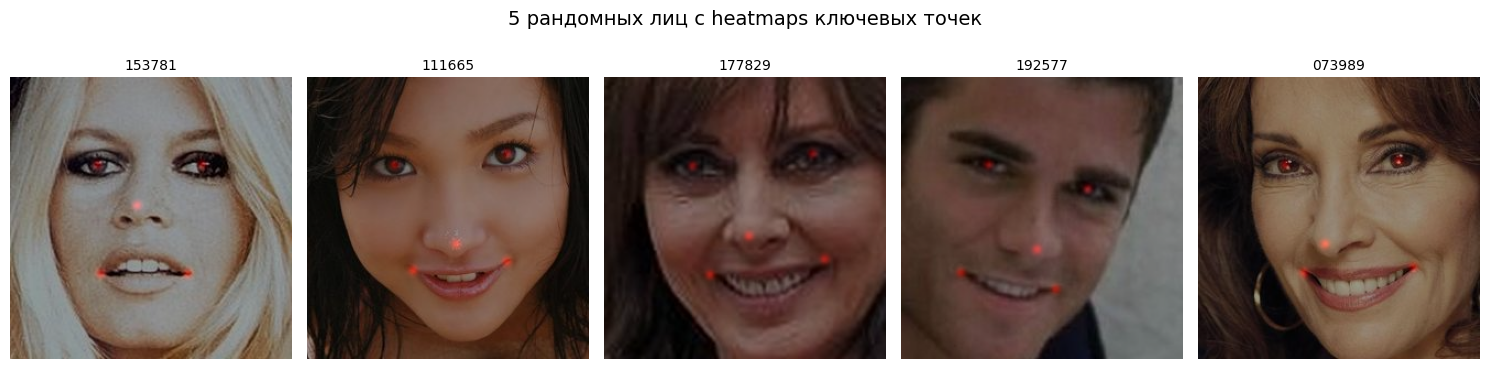

In [ ]:
num_samples = 5                                   # сколько изображений показать
sigma = 3                                       # размытие heatmap

# 5 рандомных image_id из landmarks_cropped
sample_ids = random.sample(list(landmarks_cropped['image_id']), num_samples)

# Визуализация
fig, axes = plt.subplots(1, num_samples, figsize=(15, 4))
axes = axes.ravel()

for i, image_id in enumerate(sample_ids):
    # загружаем изображение
    img_path = os.path.join(output_dir, image_id)
    if not os.path.exists(img_path):
        axes[i].set_title(f"Не найдено: {image_id}")
        axes[i].axis('off')
        continue

    img = Image.open(img_path).convert('RGB')
    img_array = np.array(img)  # [H, W, 3]
    H, W = img_array.shape[:2]

    # landmarks для выбранного image_id
    lm_row = landmarks_cropped[landmarks_cropped['image_id'] == image_id].iloc[0]
    landmarks = [
        (lm_row['lefteye_x'], lm_row['lefteye_y']),
        (lm_row['righteye_x'], lm_row['righteye_y']),
        (lm_row['nose_x'], lm_row['nose_y']),
        (lm_row['leftmouth_x'], lm_row['leftmouth_y']),
        (lm_row['rightmouth_x'], lm_row['rightmouth_y'])
    ]

    heatmaps = landmarks_to_heatmaps((H, W), landmarks, sigma=sigma)  # [5, H, W]

    # суммируем все heatmaps в один (иначе будет для каждрой точки своя хитмапа)
    combined_heatmap = np.sum(heatmaps, axis=0)  # [H, W]
    combined_heatmap /= combined_heatmap.max()  # нормируем на [0, 1]

    # Накладываем heatmap на изображение
    # Увеличиваем контраст heatmap для видимости
    heatmap_overlay = np.zeros_like(img_array)
    heatmap_overlay[:, :, 0] = (combined_heatmap * 255).astype(np.uint8)  # красный канал
    # Смешиваем с исходным изображением
    blended = np.clip(img_array * 0.6 + heatmap_overlay * 0.4, 0, 255).astype(np.uint8)

    # Отображаем
    axes[i].imshow(blended)
    axes[i].set_title(image_id.split('.')[0], fontsize=10)
    axes[i].axis('off')


plt.suptitle("5 рандомных лиц с heatmaps ключевых точек", fontsize=14)
plt.tight_layout()
plt.show()

## Реализация Hourglass блока

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.skip = nn.Identity() if in_channels == out_channels else nn.Conv2d(in_channels, out_channels, 1)

        self.conv1 = nn.Conv2d(in_channels, out_channels // 2, 1)
        self.bn1 = nn.BatchNorm2d(out_channels // 2)
        self.conv2 = nn.Conv2d(out_channels // 2, out_channels // 2, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels // 2)
        self.conv3 = nn.Conv2d(out_channels // 2, out_channels, 1)
        self.bn3 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        residual = self.skip(x)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.bn3(self.conv3(x))
        return self.relu(x + residual)

In [ ]:
class HourglassBlock(nn.Module):
    def __init__(self, depth, in_channels, out_channels, pool=nn.MaxPool2d(2, 2), upsample=nn.Upsample(scale_factor=2, mode='nearest')):
        """
        :param depth: глубина рекурсии (количество уровней down/upsampling)
        :param in_channels: количество входных каналов
        :param out_channels: количество выходных каналов
        :param pool: слой для downsampling (например, nn.MaxPool2d или nn.Conv2d)
        :param upsample: слой для upsampling (например, nn.Upsample или nn.ConvTranspose2d)
        """
        super(HourglassBlock, self).__init__()
        self.depth = depth
        self.pool = pool
        self.upsample = upsample

        # bottleneck
        self.bottleneck = ResidualBlock(in_channels, out_channels)

        # Энкодер
        self.encoder = nn.ModuleList([
            ResidualBlock(in_channels, out_channels) for _ in range(depth)
        ])

        # Декодер
        self.decoder = nn.ModuleList([
            ResidualBlock(in_channels, out_channels) for _ in range(depth)
        ])

        # Рекурсивный Hourglass (если depth > 1)
        if depth > 1:
            self.hourglass = HourglassBlock(depth - 1, in_channels, out_channels, pool, upsample)

    def forward(self, x):
        #print(f"Входной тензор: {x.shape}")  # Отладка: проверка входного размера

        # Энкодер: downsampling + ResidualBlock
        encoded = []
        for i, encoder_block in enumerate(self.encoder):
            x = encoder_block(x)
            encoded.append(x.clone())  # Сохраняем копию для skip-connection
            x = self.pool(x)  # Downsampling
            #print(f"После энкодера[{i}]: {x.shape}")  # Отладка

        # Нижний уровень (bottleneck)
        x = self.bottleneck(x)
        #print(f"После bottleneck: {x.shape}")  # Отладка

        # Если глубина > 1, применяем рекурсивный Hourglass
        if self.depth > 1:
            x = self.hourglass(x)
            #print(f"После рекурсивного hourglass: {x.shape}")  # Отладка

        # Декодер: upsampling + ResidualBlock + skip-connection
        for i in range(self.depth):
            x = self.upsample(x)  # Upsampling
            #print(f"После upsample[{i}]: {x.shape}")  # Отладка

            # Проверка совместимости skip-connection по каналам
            skip = encoded[-(i + 1)]
            if skip.shape[1]!= x.shape[1]:  # Если число каналов не совпадает
                # Преобразуем skip-connection к нужному числу каналов
                skip = nn.Conv2d(skip.shape[1], x.shape[1], 1)(skip)
                #print(f"Преобразование skip-connection: {skip.shape} -> {x.shape[1]} каналов")  # Отладка

            # Проверка совместимости по пространственному размеру
            if skip.shape[2:] != x.shape[2:]:
                skip = F.interpolate(skip, size=x.shape[2:], mode='nearest')
                #print(f"Интерполяция skip-connection: {skip.shape[2:]} -> {x.shape[2:]}")  # Отладка

            x = x + skip  # Skip-connection
            x = self.decoder[i](x)  # ResidualBlock
            #print(f"После декодера[{i}]: {x.shape}")  # Отладка

        #print(f"Выходной тензор: {x.shape}")  # Отладка
        return x


Ниже отладка, с проверкой на вывод

In [ ]:
# Создаём Hourglass-блок глубиной 2, 64 входных и 64 выходных каналов
hourglass = HourglassBlock(depth=2, in_channels=64, out_channels=64)

x = torch.randn(1, 64, 256, 256)  # вектор для проверки
output = hourglass(x)
print(output.shape)

torch.Size([1, 64, 256, 256])


## Реализация Stacked Hourglass

In [ ]:
class StackedHourglass(nn.Module):
    def __init__(self, num_stacks=2, in_channels=256, num_joints=5):
        super(StackedHourglass, self).__init__()
        self.num_stacks = num_stacks
        self.hourglass_blocks = nn.ModuleList([
            HourglassBlock(depth=2, in_channels=in_channels, out_channels=in_channels)
            for _ in range(num_stacks)
        ])

        # Линейный слой для предсказания heatmaps на выходе каждого стека
        self.conv_out = nn.Conv2d(in_channels, num_joints, 1)

        # Инициализация весов
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.normal_(m.weight, std=0.001)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        outputs = []
        for i in range(self.num_stacks):
            x = self.hourglass_blocks[i](x)
            # Увеличиваем выход Hourglass до 256x256
            x_up = F.interpolate(x, size=(256, 256), mode='bilinear', align_corners=False)
            pred = self.conv_out(x_up)  # [B, num_joints, 256, 256]
            outputs.append(pred)  # Промежуточные предсказания (heatmaps)
        return outputs  # Список из num_stacks heatmaps

In [ ]:
class InitialConv(nn.Module):
    def __init__(self, in_channels=3, out_channels=256):
        super(InitialConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, 64, 7, stride=2, padding=3),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(3, stride=2, padding=1),
            ResidualBlock(64, 64),
            nn.Conv2d(64, out_channels, 1)
        )

    def forward(self, x):
        return self.conv(x)

In [ ]:
class FullStackedHourglass(nn.Module):
    def __init__(self, num_stacks=2, num_joints=5):
        super(FullStackedHourglass, self).__init__()
        self.initial_conv = InitialConv(in_channels=3, out_channels=256)
        self.stacked_hourglass = StackedHourglass(num_stacks, in_channels=256, num_joints=num_joints)

    def forward(self, x):
        x = self.initial_conv(x)  # Приводим к 256 каналам
        return self.stacked_hourglass(x)  # Получаем список heatmaps

## Подготовка датасета

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

In [ ]:
class CelebaHeatmapDataset(Dataset):
    def __init__(self, images_dir, landmarks_df, transform=None, sigma=2):
        """
        :param images_dir: путь к папке с изображениями (/content/celeba_cropped)
        :param landmarks_df: pandas DataFrame с колонками: image_id, lefteye_x, lefteye_y, ...
        :param transform: трансформации для изображения (например, resize + normalize)
        :param sigma: параметр для heatmap (размытие)
        """
        self.images_dir = images_dir
        self.landmarks_df = landmarks_df
        self.transform = transform
        self.sigma = sigma

        # Список всех image_id из DataFrame (которые есть в папке)
        self.image_ids = []
        for img_name in os.listdir(images_dir):
            if img_name in landmarks_df['image_id'].values:
                self.image_ids.append(img_name)

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        img_path = os.path.join(self.images_dir, image_id)


        # Загружаем изображение
        image = Image.open(img_path).convert('RGB')
        W, H = image.size  # W - weight, H - height

        # Получаем landmarks для этого image_id
        row = self.landmarks_df[self.landmarks_df['image_id'] == image_id].iloc[0]

        landmarks = [
            (row['lefteye_x'], row['lefteye_y']),
            (row['righteye_x'], row['righteye_y']),
            (row['nose_x'], row['nose_y']),
            (row['leftmouth_x'], row['leftmouth_y']),
            (row['rightmouth_x'], row['rightmouth_y'])
        ]

        # Преобразуем landmarks в heatmaps [5, H, W]
        heatmaps = landmarks_to_heatmaps((H, W), landmarks, sigma=self.sigma)

        # Применяем трансформации к изображению (если заданы)
        if self.transform:
            image = self.transform(image)

        # Конвертируем heatmaps в Tensor
        heatmaps = torch.from_numpy(heatmaps).float()


        return image, heatmaps, image_id  # [3, H, W], [5, H, W], str

In [ ]:
# Трансформации: resize > toTensor > normalize
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Создаём датасет
dataset = CelebaHeatmapDataset(
    images_dir='/content/celeba_cropped',
    landmarks_df=landmarks_cropped,
    transform=transform,
    sigma=2
)

In [ ]:
from torch.utils.data import random_split

# Общее число примеров
total_size = len(dataset)
train_size = int(0.8 * total_size)
test_size = total_size - train_size

# Разделяем
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])


# DataLoader для обучения и валидации
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2)

## Обучение Stacked Hourglass

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = FullStackedHourglass(num_stacks=2, num_joints=5)  # 5 ключевых точек
model = model.to(device)
model

FullStackedHourglass(
  (initial_conv): InitialConv(
    (conv): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (4): ResidualBlock(
        (skip): Identity()
        (conv1): Conv2d(64, 32, kernel_size=(1, 1), stride=(1, 1))
        (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1))
        (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
      )
      (5): Conv2d(64, 256, kernel_size=(1,

In [ ]:
import torch.optim as optim

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)  # Снижение LR

In [ ]:
num_epochs = 13
epoch_losses = []  # Сюда будем сохранять средний loss каждой эпохи


for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for batch_idx, (images, heatmaps, image_ids) in enumerate(train_loader):
        images, heatmaps = images.to(device), heatmaps.to(device)

        # Обнуляем градиенты
        optimizer.zero_grad()

        # Прогоняем через сеть
        outputs = model(images)  # список из num_stacks тензоров [B, 17, H, W]

        # Вычисляем суммарную потерю
        total_loss = 0.0
        for output in outputs:
            loss = criterion(output, heatmaps)
            total_loss += loss

        # Обратное распространение
        total_loss.backward()
        optimizer.step()

        running_loss += total_loss.item()

        if batch_idx % 100 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Step [{batch_idx}/{len(train_loader)}], '
                  f'Loss: {total_loss.item():.4f}')

    # Средний loss за эпоху
    avg_loss = running_loss / len(train_loader)
    epoch_losses.append(avg_loss)

    scheduler.step()  # Обновляем LR
    print(f'Epoch [{epoch+1}/{num_epochs}], Avg Loss: {avg_loss:.4f}')

Epoch [1/13], Step [0/416], Loss: 0.2328
Epoch [1/13], Step [100/416], Loss: 0.0012
Epoch [1/13], Step [200/416], Loss: 0.0008
Epoch [1/13], Step [300/416], Loss: 0.0006
Epoch [1/13], Step [400/416], Loss: 0.0006
Epoch [1/13], Avg Loss: 0.0173
Epoch [2/13], Step [0/416], Loss: 0.0005
Epoch [2/13], Step [100/416], Loss: 0.0005
Epoch [2/13], Step [200/416], Loss: 0.0005
Epoch [2/13], Step [300/416], Loss: 0.0005
Epoch [2/13], Step [400/416], Loss: 0.0005
Epoch [2/13], Avg Loss: 0.0005
Epoch [3/13], Step [0/416], Loss: 0.0004
Epoch [3/13], Step [100/416], Loss: 0.0005
Epoch [3/13], Step [200/416], Loss: 0.0005
Epoch [3/13], Step [300/416], Loss: 0.0005
Epoch [3/13], Step [400/416], Loss: 0.0005
Epoch [3/13], Avg Loss: 0.0005
Epoch [4/13], Step [0/416], Loss: 0.0005
Epoch [4/13], Step [100/416], Loss: 0.0005
Epoch [4/13], Step [200/416], Loss: 0.0004
Epoch [4/13], Step [300/416], Loss: 0.0005
Epoch [4/13], Step [400/416], Loss: 0.0004
Epoch [4/13], Avg Loss: 0.0004
Epoch [5/13], Step [0/41

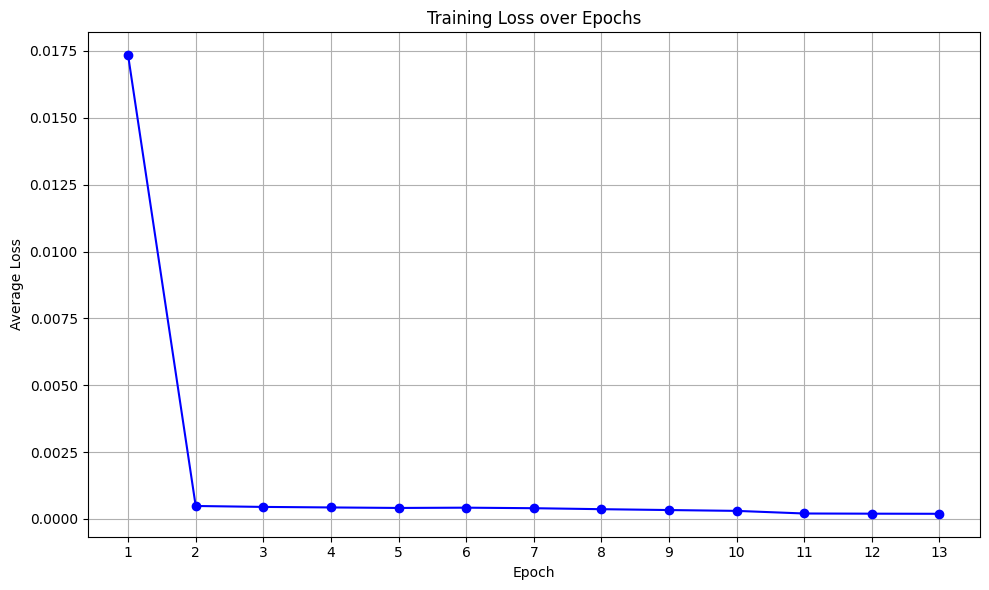

In [ ]:
# Визуализация Loss
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs + 1), epoch_losses, marker='o', linestyle='-', color='blue')
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.grid(True)
plt.xticks(range(1, num_epochs + 1))
plt.tight_layout()
plt.show()

Валидируем:

In [ ]:
def validate(model, val_loader):
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, heatmaps, image_ids in val_loader:
            images, heatmaps = images.to(device), heatmaps.to(device)
            outputs = model(images)
            for output in outputs:
                val_loss += criterion(output, heatmaps).item()
    return val_loss / len(val_loader)

In [ ]:
val_loss = validate(model, test_loader)
print(f"Валидационный loss: {val_loss:.4f}")

Валидационный loss: 0.0002


Получился хороший результат на валидации, можно сохранять обученную модель

In [ ]:
# Сохранение
torch.save(model.state_dict(), 'stacked_hourglass.pth')

# Загрузка (проверка)
model.load_state_dict(torch.load('stacked_hourglass.pth'))

<All keys matched successfully>

Проверим, как она поднимается из сохраненного файла:

In [ ]:
model = FullStackedHourglass(num_stacks=2, num_joints=5)
model.load_state_dict(torch.load('/content/stacked_hourglass.pth'))
model.to(device)
model.eval()  # режим инференса

FullStackedHourglass(
  (initial_conv): InitialConv(
    (conv): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (4): ResidualBlock(
        (skip): Identity()
        (conv1): Conv2d(64, 32, kernel_size=(1, 1), stride=(1, 1))
        (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1))
        (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
      )
      (5): Conv2d(64, 256, kernel_size=(1,

Все ок с моделью.

Теперь посмотрим н аключевые точки, котоые она предсказала.

In [ ]:
def visualize_landmarks(model, test_dataset, transform, device, num_samples=5, figsize=(15, 10)):
    """
    Визуализирует 5 случайных изображений из test_dataset с ключевыми точками,
    предсказанными моделью.

    Параметры:
    - model: обученная модель (возвращает список тепловых карт)
    - test_dataset: датасет (должен возвращать (image, heatmap, image_id))
    - transform: трансформации для инференса
    - device: устройство ('cuda' или 'cpu')
    - num_samples: число изображений для визуализации (по умолчанию 5)
    - figsize: размер фигуры matplotlib
    """
    # Выбираем случайные индексы
    indices = random.sample(range(len(test_dataset)), num_samples)

    plt.figure(figsize=figsize)

    for i, idx in enumerate(indices):
        # Загружаем данные
        image, _, image_id = test_dataset[idx]

        #orig_image = Image.open(image_id).convert('RGB')  # Исходное изображение
        image_path = os.path.join('/content/celeba_cropped/', image_id)  # полный путь
        orig_image = Image.open(image_path).convert('RGB')

        # Препроцессинг для модели
        input_image = transform(orig_image).unsqueeze(0).to(device)

        # Инференс
        model.eval()
        with torch.no_grad():
            outputs = model(input_image)
            final_heatmap = outputs[-1]  # Последняя тепловая карта [1, C, H, W]

        # Находим ключевые точки
        keypoints = []
        for c in range(final_heatmap.shape[1]):  # Цикл по каналам (точкам)
            joint_heatmap = final_heatmap[0, c, :, :]  # [H, W]
            if torch.isnan(joint_heatmap).any() or torch.isinf(joint_heatmap).any():
                keypoints.append((0, 0))
                continue

            max_val = joint_heatmap.max()
            h_indices, w_indices = torch.where(joint_heatmap == max_val)


            if h_indices.numel() == 0:
                keypoints.append((0, 0))
            else:
                h, w = h_indices[0].item(), w_indices[0].item()
                keypoints.append((w, h))  # (x, y)

        # Визуализация
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(orig_image)
        x_coords, y_coords = zip(*keypoints)
        plt.scatter(x_coords, y_coords, c='red', s=20, edgecolors='white', linewidth=1.5)
        plt.title(f'Image ID: {image_id.split("/")[-1]}')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

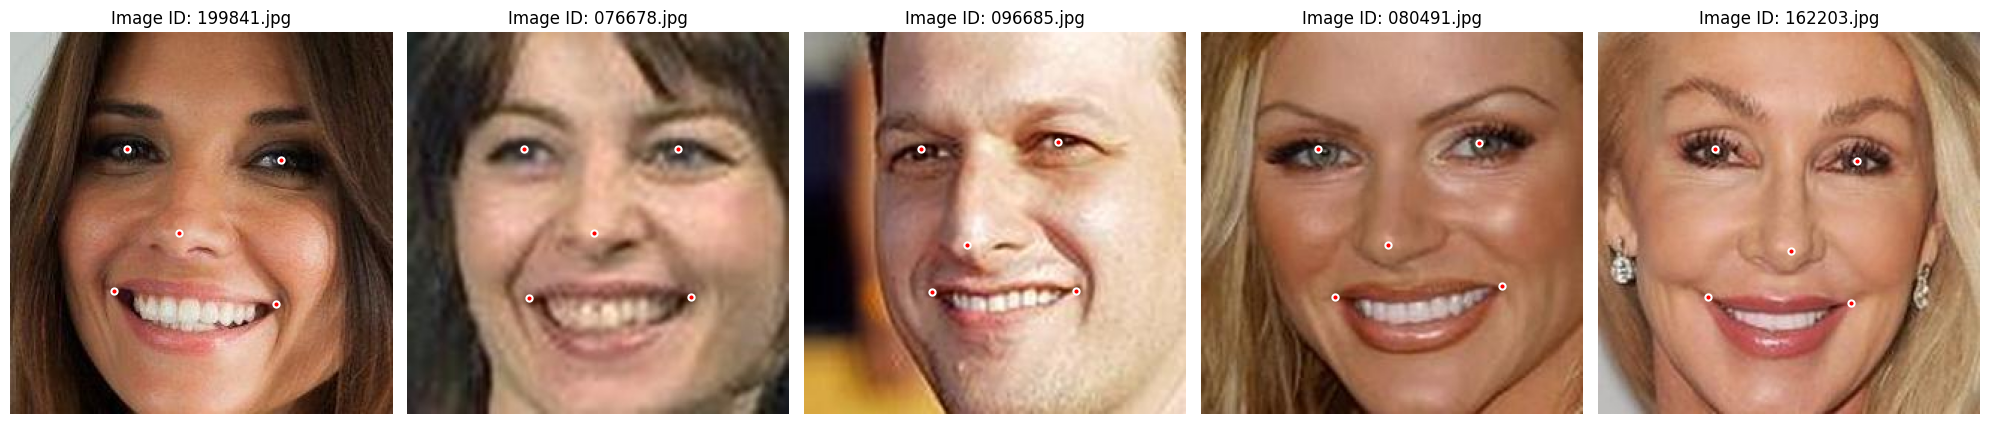

In [ ]:
visualize_landmarks(
    model=model,
    test_dataset=test_dataset,
    transform=transform,
    device=device,
    num_samples=5,
    figsize=(20, 8)
)

С рандомными изображдениями все отлично.
Посмотрим еще на сырые предсказания, на всякий случай.

In [ ]:
def visualize_heatmaps(model, test_dataset, transform, device, num_samples=5, figsize=(15, 10), cmap='hot'):
    """
    Визуализирует 5 случайных тепловых карт (без перевода в точки) из test_dataset.

    Параметры:
    - model: обученная модель (возвращает список тепловых карт)
    - test_dataset: датасет (должен возвращать (image, heatmap, image_id))
    - transform: трансформации для инференса
    - device: устройство ('cuda' или 'cpu')
    - num_samples: число изображений для визуализации (по умолчанию 5)
    - figsize: размер фигуры matplotlib
    - cmap: цветовая карта для отображения heatmap (по умолчанию 'hot')
    """
    # Выбираем случайные индексы
    indices = random.sample(range(len(test_dataset)), num_samples)

    plt.figure(figsize=figsize)

    for i, idx in enumerate(indices):
        # Загружаем данные
        image, true_heatmap, image_id = test_dataset[idx]

        # Формируем полный путь к изображению (для подписи)
        image_path = os.path.join('/content/celeba_cropped/', image_id)

        # Препроцессинг для модели
        input_image = transform(Image.open(image_path).convert('RGB')).unsqueeze(0).to(device)

        # Инференс
        model.eval()
        with torch.no_grad():
            outputs = model(input_image)
            final_heatmap = outputs[-1]  # Последняя тепловая карта [1, C, H, W]

        # Визуализируем каждую тепловую карту (по каналам)
        num_channels = final_heatmap.shape[1]
        for c in range(num_channels):
            plt.subplot(num_samples, num_channels, i * num_channels + c + 1)

            # Берем одну тепловую карту и переводим в numpy
            heatmap_np = final_heatmap[0, c, :, :].cpu().numpy()

            plt.imshow(heatmap_np, cmap=cmap, interpolation='bilinear')
            plt.title(f'Img: {image_id} | Ch: {c}')
            plt.axis('off')

    plt.tight_layout()
    plt.show()

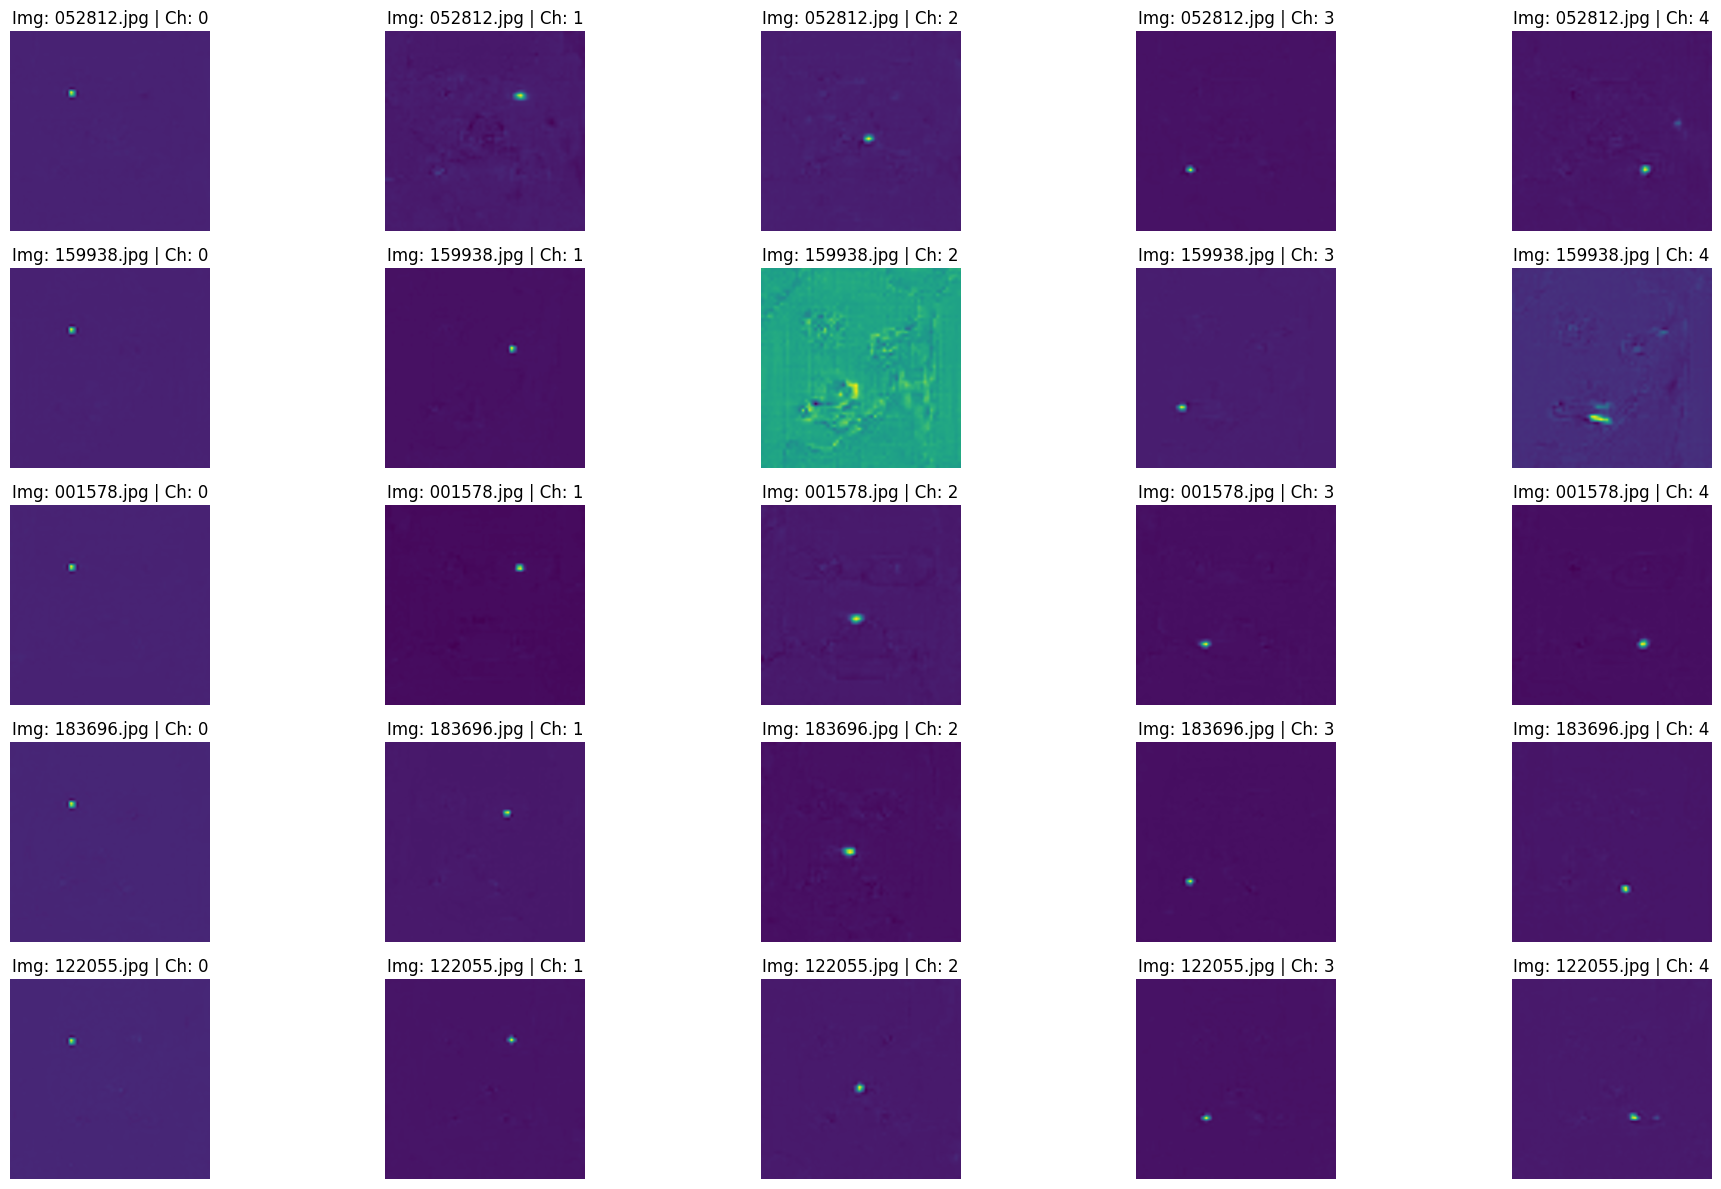

In [ ]:
visualize_heatmaps(
    model=model,
    test_dataset=test_dataset,
    transform=transform,
    device=device,
    num_samples=5,
    figsize=(20, 12),
    cmap='viridis'  # можно поменять цветовую схему
)

Сырые карты тоже неплохие. (Кроме одной, ну что же, бывают и такие ошибки.

## Выравнивание по предсказанным точкам

Существует множество вариантов, как по полученным точкам правильно преобразовать картинку. Главное, что вам нужно понимать - **это задача классического компьютерного зрения** и решается при помощи математики, без нейронок. Вдаваться в подробности конкретных алгоритмов мы не будем.

Можно использовать аффинное преобразование, тогда потребуется только 3 точки, можно, например, искать матрицу гомографии, где может быть использовано больше точек, а может быть, есть еще что-то. Реализовывать эти алгоритмы самим не нужно. Достаточно провести небольшой ресерч и найти готовое решение (но **не готовую нейронку для выравнивания**), лишь бы оно работало. Количество используемых точек тоже выбирайте сами, подойдет любой вариант. Условный ориентир для поиска - библиотека **opencv**. Обязательно приведите примеры того, как работает ваш алгоритм.

In [ ]:
import cv2
import torchvision.transforms as T

In [ ]:
# Пути
IMG_DIR = '/content/celeba_cropped'
MODEL_PATH = '/content/stacked_hourglass.pth'
OUTPUT_DIR = '/content/aligned_celeba_predicted'

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Целевые точки (эталон)
DST_POINTS = np.float32([
    [80, 80],   # левый глаз
    [176, 80],  # правый глаз
    [128, 140]  # нос
])

# Функция выравнивания
def align_image_affine(pil_image, src_points, dst_points):
    img = np.array(pil_image)
    img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    M = cv2.getAffineTransform(src_points, dst_points)
    aligned_bgr = cv2.warpAffine(img_bgr, M, (256, 256))
    aligned_rgb = cv2.cvtColor(aligned_bgr, cv2.COLOR_BGR2RGB)
    return Image.fromarray(aligned_rgb)


# Датасет — загрузка и трансформация изображений (без landmarks)
class InferenceDataset(Dataset):
    def __init__(self, images_dir, transform=None):
        self.images_dir = images_dir
        valid_exts = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp')
        self.image_ids = [
            f for f in os.listdir(images_dir)
            if os.path.isfile(os.path.join(images_dir, f))
            and f.lower().endswith(valid_exts)
        ]
        self.transform = transform

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        img_path = os.path.join(self.images_dir, image_id)
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)
        return image, image_id

# Трансформации: resize > toTensor > normalize
transform = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Создаём датасет и DataLoader
dataset = InferenceDataset(IMG_DIR, transform=transform)
dataloader = DataLoader(dataset, batch_size=1, shuffle=False)


# Загружаем модель
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FullStackedHourglass(num_stacks=2, num_joints=5)  # 5 ключевых точек
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()
model.to(device)

# Цикл: обработка каждого изображения
with torch.no_grad():
    for image_tensor, image_id in dataloader:
        image_tensor = image_tensor.to(device)  # [1, 3, 256, 256]


        # Предсказываем heatmaps
        outputs = model(image_tensor)  # list из 2 тензоров [1, 5, H, W]
        heatmaps = outputs[-1]  # берём последний выход [1, 5, 256, 256]


        # Извлекаем координаты 5 точек из heatmaps (argmax по H,W)
        pred_points = []
        for j in range(5):  # для каждой из 5 точек
            heatmap = heatmaps[0, j, :, :].cpu().numpy()  # [256, 256]
            y, x = np.unravel_index(np.argmax(heatmap), heatmap.shape)
            pred_points.append([x, y])
        pred_points = np.float32(pred_points)  # [5, 2]

        # Берём только 3 точки: левый глаз (0), правый глаз (1), нос (2)
        src_points = pred_points[:3]  # [3, 2]

        # Загружаем исходное PIL-изображение для выравнивания
        img_path = os.path.join(IMG_DIR, image_id[0])
        image_pil = Image.open(img_path).convert('RGB')

        # Выравниваем
        aligned_pil = align_image_affine(image_pil, src_points, DST_POINTS)

        # Сохраняем
        aligned_pil.save(os.path.join(OUTPUT_DIR, image_id[0]))
        #print(f"Обработано: {image_id[0]}")

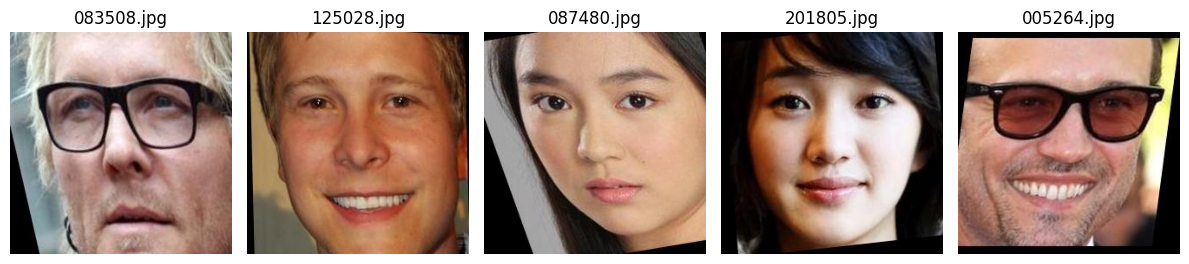

In [ ]:
# Визуализация 5 случайных результатов
files = os.listdir(OUTPUT_DIR)
selected = random.sample(files, 5)

fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i, filename in enumerate(selected):
    img = Image.open(os.path.join(OUTPUT_DIR, filename))
    axes[i].imshow(img)
    axes[i].set_title(filename)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

Все хорошо с выровненными изображениями

In [ ]:
folder_path = '/content/aligned_celeba_predicted'

# Проверяем, существует ли папка
if not os.path.exists(folder_path):
    print(f"Папка не найдена: {folder_path}")
else:
    # Получаем список файлов (исключая подкаталоги)
    files = [f for f in os.listdir(folder_path)
             if os.path.isfile(os.path.join(folder_path, f))]

    file_count = len(files)
    print(f"Количество файлов в папке '{folder_path}': {file_count}")

Количество файлов в папке '/content/aligned_celeba_predicted': 16686


Отлично, количество файлов в папке с выровненими файлами соответствует количеств уисходных файлов. можнол сохранять папку для дальнейшего этапа.

## Сохранение на диск

Сохраняем папку с файлами:

In [ ]:
import os
import shutil

# Путь к папке с исходными картинками
source_folder = '/content/aligned_celeba_predicted'

# Целевая папка на Google Диске
target_folder = '/content/drive/MyDrive/DLS1/aligned_images'

# Создаём целевую папку, если её нет
os.makedirs(target_folder, exist_ok=True)


# Счётчики
copied_count = 0
failed_count = 0
failed_files = []  # для записи имён неудачных файлов


# Перебираем файлы в исходной папке
for filename in os.listdir(source_folder):
    source_path = os.path.join(source_folder, filename)
    target_path = os.path.join(target_folder, filename)

    # Проверяем, что это файл (а не папка)
    if os.path.isfile(source_path):
        try:
            shutil.copy2(source_path, target_path)
            copied_count += 1
        except Exception as e:
            failed_count += 1
            failed_files.append(f"{filename} (ошибка: {e})")


# Выводим итоги
print(f"Итого файлов в исходной папке: {len(os.listdir(source_folder))}")
print(f"Скопировано файлов: {copied_count}")
print(f"Не удалось скопировать: {failed_count}")


# Если были ошибки — выводим список проблемных файлов
if failed_files:
    print("\nСписок файлов с ошибками:")
    for problem in failed_files:
        print(f"  - {problem}")


print("\nФайлы успешно скопированы в DLS1!")

Итого файлов в исходной папке: 16686
Скопировано файлов: 16686
Не удалось скопировать: 0

Файлы успешно скопированы в DLS1!


Копируем модель на диск

In [ ]:
source_file = '/content/stacked_hourglass.pth'
target_dir = '/content/drive/MyDrive/DLS1'
target_path = os.path.join(target_dir, 'stacked_hourglass.pth')

shutil.copy2(source_file, target_path)

'/content/drive/MyDrive/DLS1/stacked_hourglass.pth'

Проверяем количество скопированных файлов (копировала не зип-архив потому, что в архиве оказывалось всегда меньше файлов, чем я отправляла на архивирование, пришлось делать так)

In [ ]:
# Получаем список имён файлов из папки
file_names = set(os.listdir(source_folder))
print(f"Количество файлов в папке '{source_folder}': {len(file_names)}")

print(f"Исходное количество строк в датасете: {len(person_id)}")

# Фильтруем датасет: оставляем только строки, где img_id есть в списке файлов папки
person_id_aligned = person_id[person_id['image_id'].isin(file_names)].reset_index(drop=True)

# Выводим результаты
print(f"Количество строк в отфильтрованном датасете: {len(person_id_aligned)}")
print(f"Удалено строк (img_id не найдено в папке): {len(person_id) - len(person_id_aligned)}")

# Дополнительная проверка: есть ли файлы из датасета, которых нет в папке?
missing_in_folder = set(person_id['image_id']) - file_names
if missing_in_folder:
    print(f"\nВнимание: в датасете есть {len(missing_in_folder)} img_id, отсутствующих в папке:")
    # Печатаем первые 10, чтобы не загромождать вывод
    print(list(missing_in_folder)[:10])
else:
    print("\nВсе img_id из датасета присутствуют в папке.")



Количество файлов в папке '/content/aligned_celeba_predicted': 16686
Исходное количество строк в датасете: 16686
Количество строк в отфильтрованном датасете: 16686
Удалено строк (img_id не найдено в папке): 0

Все img_id из датасета присутствуют в папке.


Сохраняем person_id на всякий случай

In [ ]:
folder_path = "/content/drive/MyDrive/DLS1/"

csv_filename = "person_id_aligned.csv"
csv_full_path = folder_path + csv_filename

person_id_aligned.to_csv(csv_full_path)

In [ ]:
# Список файлов в корне Drive
!ls "/content/drive/MyDrive/DLS1/"

aligned_images	    landmarks_cropped.csv  stacked_hourglass.pth
attrs.csv	    person_id_aligned.csv
celeba_cropped.zip  person_id.csv


А вот теперь на самом диске мы создадим архив из имеющейся там папки, чтобы проще было его скачивать.

In [ ]:
source_folder = '/content/drive/MyDrive/DLS1/aligned_images'

In [ ]:
# Имя архива
zip_filename = 'aligned_images.zip'

# Создаём архив (рекурсивно, с подпапками)
!zip -r "{zip_filename}" "{source_folder}"

Выходные данные были обрезаны до нескольких последних строк (5000).
  adding: content/drive/MyDrive/DLS1/aligned_images/105420.jpg (deflated 1%)
  adding: content/drive/MyDrive/DLS1/aligned_images/181974.jpg (deflated 2%)
  adding: content/drive/MyDrive/DLS1/aligned_images/009901.jpg (deflated 2%)
  adding: content/drive/MyDrive/DLS1/aligned_images/102514.jpg (deflated 1%)
  adding: content/drive/MyDrive/DLS1/aligned_images/090138.jpg (deflated 7%)
  adding: content/drive/MyDrive/DLS1/aligned_images/025786.jpg (deflated 2%)
  adding: content/drive/MyDrive/DLS1/aligned_images/168253.jpg (deflated 3%)
  adding: content/drive/MyDrive/DLS1/aligned_images/192123.jpg (deflated 1%)
  adding: content/drive/MyDrive/DLS1/aligned_images/078750.jpg (deflated 2%)
  adding: content/drive/MyDrive/DLS1/aligned_images/039141.jpg (deflated 1%)
  adding: content/drive/MyDrive/DLS1/aligned_images/176423.jpg (deflated 1%)
  adding: content/drive/MyDrive/DLS1/aligned_images/021666.jpg (deflated 3%)
  adding

In [ ]:
dest_path = '/content/drive/MyDrive/DLS1/aligned_images.zip'  # путь на Диске
!cp "{zip_filename}" "{dest_path}"

In [ ]:
!ls "/content/drive/MyDrive/DLS1/"

total 320778
drwx------ 2 root root      4096 Feb  4 18:16 aligned_images
-rw------- 1 root root 150243926 Feb  4 19:51 aligned_images.zip
-rw------- 1 root root   2129751 Feb  3 12:56 attrs.csv
-rw------- 1 root root 160010304 Feb  3 12:56 celeba_cropped.zip
-rw------- 1 root root   1141698 Feb  3 12:56 landmarks_cropped.csv
-rw------- 1 root root    462869 Feb  4 18:17 person_id_aligned.csv
-rw------- 1 root root    373852 Feb  3 12:56 person_id.csv
-rw------- 1 root root  14107771 Feb  3 16:00 stacked_hourglass.pth


Все готово к этапу распознавания лиц.

# План заданий

По итогу, в этом блоке у вас следующие задачи:

*   Подготовить датасет, сохранить файл с оригинальными названиями изображений
*   Реализовать Hourglass блок
*   Реализовать Stacked Hourglass
*   Преобразовать точки лица в Heatmap'ы
*   Обучить Stacked Hourglass
*   Найти функцию, которая по предсказанным ключевым точкам выравнивает лица на картинке (face alignment)
*   Подготовить датасет с кропнутыми и выровненными лицами для следующего этапа

**P.S. Не забывайте сохранять модели после обучения и выводите промежуточные результаты на экран**



**Удачи! У вас всё получится 💗!**